<a href="https://colab.research.google.com/github/ritashreemukherjee123/PYTHON__--full--/blob/main/ACME_(Medical_Inc_)Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis on the ACME Insurance Dataset. With proper EDA and visualization, we analyse the dataset and understand patterns of it.


In [ ]:
import pandas as pd
import numpy as np

**ACME Dataset.**

   A Kaggle competition dataset used to forecast the annual medical expenditure or retail purchase amount of customers based on factors like age, BMI, children, smoking habits, and region of residence.

In [ ]:
df = pd.read_csv('/content/archive (2).zip')

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()  #shows some basic statistics of the dataset

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
#Plotting the dataset and performing some EDA(Exploratory data analysis)
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

Age is numeric column. The minimum age is 18 years and the maximum age is 64 years. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot. We'll use plotly to make the chart interactive, but you can create similar charts using Seaborn.

In [ ]:
df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [ ]:
fig = px.histogram(df, x='age', marginal = 'box', nbins = 47,
                   title = 'Distribution of Age')
fig.update_layout(bargap = 0.1)
fig.show()

The distribution of ages in the dataset is almost uniform,with 20-30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any age (between 18 & 64) in the USA.

**BODY MASS INDEX**

In [ ]:
fig = px.histogram(df,
                   x='bmi',
                   marginal = 'box',
                   color_discrete_sequence = ['hotpink'],
                   title = 'Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap = 0.1)
fig.show()

### Charges

Let's visualize the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. Let's also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='sex',
                   marginal='box',
                   color_discrete_sequence=['plum'],
                   title='Distribution of Gender')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='region',
                   marginal='box',
                   color_discrete_sequence=['orange'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

### Smoker

Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

In [ ]:
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
px.histogram(df, x='smoker', color='sex', title='Smoker')

It appears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, assuming the data was collected in 2010? We can also see that smoking appears a more common habit among males. Can you verify this?

> **EXERCISE**:
Visualize the distributions of the "sex", "region" and "children" columns and report your observations.

In [ ]:
px.histogram(df, x='sex', color='smoker', title='Sex')

In [ ]:
px.histogram(df, x='region', color='sex', title='Region')

In [ ]:
fig = px.histogram(df,
                   x='children',
                   color_discrete_sequence=['violet'], # Modified line: Using color_discrete_sequence instead of color
                   title='Number of children based on Region')
fig.show()

Having looked at individual columns, we can now visualize the relationship between "charges" (the value we wish to predict) and other columns.

### Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

In [ ]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

We can make the following observations from the above chart:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.


* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

     1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
     
     2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
     
     3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.
     

> **EXERCISE**: What other inferences can you draw from the above chart?
>
> ???

### BMI and Charges

Let's visualize the relationship between BMI (body mass index) and charges using another scatter plot. Once again, we'll use the values from the "smoker" column to color the points.

In [ ]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

What other insights can you gather from the above graph?

> **EXERCISE**: Create some more graphs to visualize how the "charges" column is related to other columns ("children", "sex", "region" and "smoker"). Summarize the insights gathered from these graphs.
>
> *Hint*: Use violin plots (`px.violin`) and bar plots (`sns.barplot`)

In [ ]:
fig = px.violin(df,  # Your DataFrame
                 y="charges",  # Column to visualize distribution
                 x="smoker",  # Column for grouping (optional)
                 color="smoker", # Column for coloring (optional)
                 box=True,  # Show box plot inside the violin
                 points="all",  # Show all data points
                 hover_data=df.columns,
                title = 'Charges vs. Smoker' )  # Show all columns on hover
fig.show()

In [ ]:
import plotly.express as px

fig = px.violin(df,
                 y="charges",
                 x="children",
                 color="children",
                 box=True,
                 points="all",
                 hover_data=df.columns,
                 title='Charges vs. Children')
fig.show()

In [ ]:
fig = px.violin(df,
                 y="charges",
                 x="sex",
                 color="sex",
                 box=True,
                 points="all",
                 hover_data=df.columns,
                 title='Charges vs. Sex')
fig.show()

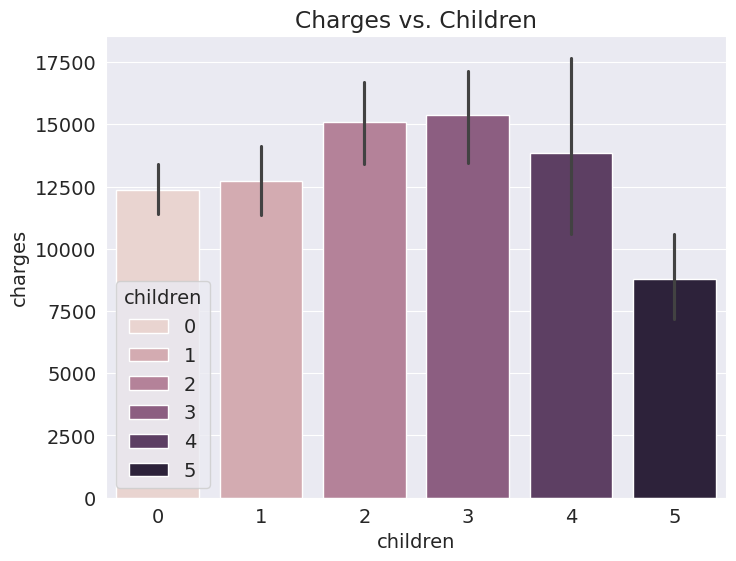

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x="children", y="charges", data=df, hue="children")
plt.title("Charges vs. Children")
plt.show()

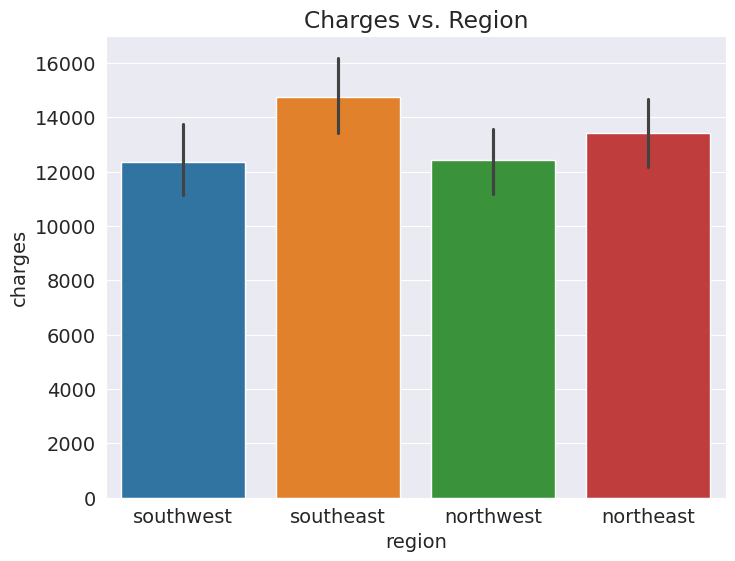

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x="region", y="charges", data=df, hue="region")
plt.title("Charges vs. Region")
plt.show()

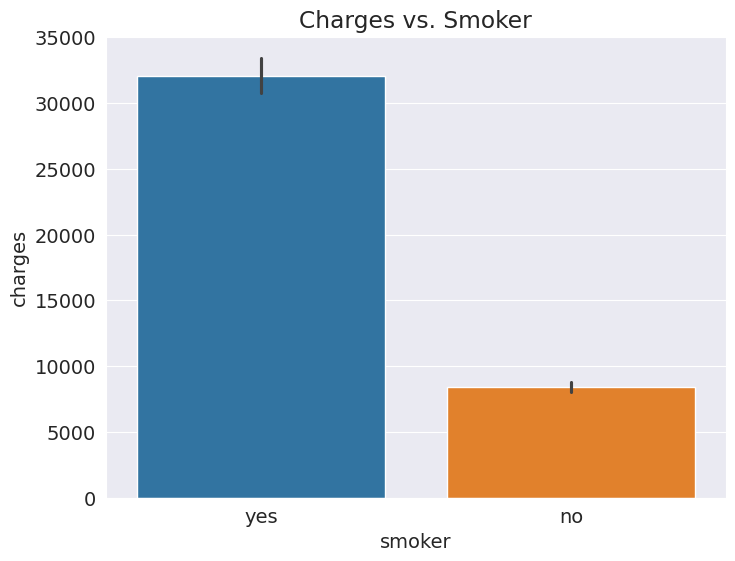

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x="smoker", y="charges", data=df, hue="smoker")
plt.title("Charges vs. Smoker")
plt.show()

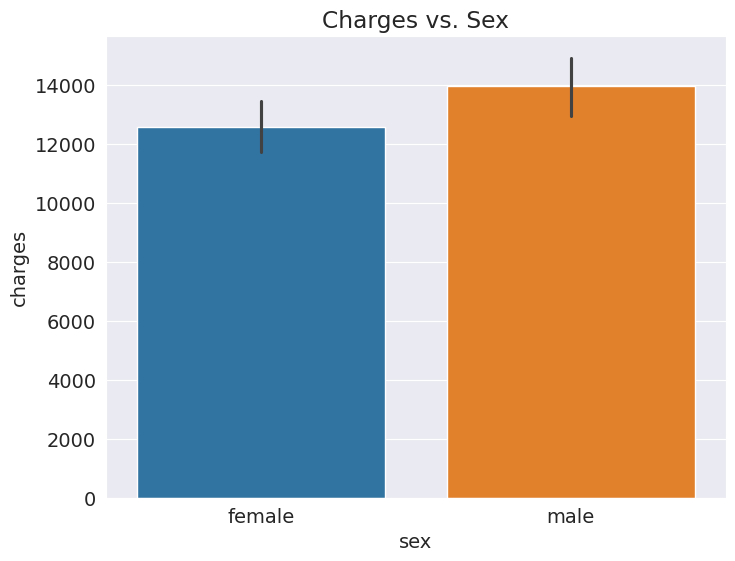

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x="sex", y="charges", data=df, hue="sex")
plt.title("Charges vs. Sex")
plt.show()